In [1]:
pwd

'/Volumes/E/Self Study Agentic AI/Lang Graph'

# BMI Calculator  using Lang Graph
BMI = Weight (kg) ÷ [Height (m)]²

##### Step 1: Define State
##### Step 2: Define the function(s) used in the nodes
##### Step 3: Define the graph
##### Step 4: Add nodes to the graph
##### Step 5: Add edges to the graph
##### Step 6: Compile the graph
##### Step 7: Invoke / execute the graph

In [7]:
#install package only first time
#pip install langgraph

In [8]:
#Define Library
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

**Why do we need State?**

LangGraph works by passing state from one node to another.<br>
state as a box containing all input and output information.

In [9]:
#Define State
class BMIState(TypedDict):
    weight_kg:float
    height_m:float
    bmi: float
    category:str

In [10]:
def calculate_bmi(state: BMIState) -> BMIState:
    #fetch state objects
    weight = state['weight_kg']
    height = state['height_m']
    bmi = weight /(height**2)

    #update the state
    state['bmi']=round(bmi,2)
    
    return state

In [11]:
def label_bmi(state: BMIState) -> BMIState:

    bmi = state['bmi']

    if bmi < 18.5:
        state["category"] = "Underweight"
    elif 18.5 <= bmi < 25:
        state["category"] = "Normal"
    elif 25 <= bmi < 30:
        state["category"] = "Overweight"
    else:
        state["category"] = "Obese"

    return state

In [16]:
#Define graph
graph=StateGraph(BMIState) #create object for graph

#add notes to the graph
#Create a node called calculate_bmi and execute the calculate_bmi function when this node runs.
graph.add_node('calculate_bmi',calculate_bmi)
graph.add_node('category_bmi',label_bmi)
#add edges to the graph
graph.add_edge(START,'calculate_bmi')
graph.add_edge('calculate_bmi','category_bmi')
graph.add_edge('category_bmi',END)

#compile the graph
workflow=graph.compile()

#execute the graph
initial_state = {'weight_kg':80, 'height_m':1.75}
final_state=workflow.invoke(initial_state)
print(final_state)

{'weight_kg': 80, 'height_m': 1.75, 'bmi': 26.12, 'category': 'Overweight'}


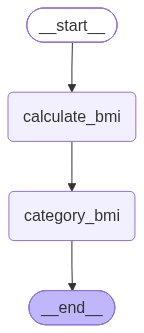

In [17]:
#Draw Graph
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())